## Imports & Dependnecies

In [32]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.sql import DataFrame
from pyspark.ml.functions import vector_to_array
import math
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

## Data Preprocessing

### Load Dataset

In [2]:
# file imports
zone_lookup_file_name = "gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_zone_lookup.csv"

### Initial Inspection

In [3]:
file_name = "gs://zz3276-ieor4526-bucket/data/4526 final project data/trip_records/"
raw_df = spark.read.parquet(file_name)

raw_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [4]:
raw_df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-05-01 00:07:06|  2025-05-01 00:24:15|              1|          3.7|         1|                 N|         140|    

### Data Cleaning & Feature Engineering

In [5]:
def data_cleaning(df: DataFrame): 
    
    # 1. Basic cleaning, keep credit card records and remove trips with invalid fares & distances
    fare_cols = [
        "fare_amount",
        "extra",
        "mta_tax",
        "tip_amount",
        "tolls_amount",
        "improvement_surcharge",
        "total_amount",
        "congestion_surcharge",
        "Airport_fee",
        "cbd_congestion_fee"
    ]
    
    # All fare-related columns must be >= 0
    fare_nonneg_condition = reduce(
        lambda a, b: a & b,
        [col(c) >= 0 for c in fare_cols]
    )

    cleaned_df = (
        df.fillna(0, subset=fare_cols)
          .filter(col("payment_type") == 1) # credit card payment trips only
          .filter(col("fare_amount") > 0)   # ensure positive for total fares
          .filter(col("total_amount") > 0)
          .filter(col("trip_distance") > 0) # valid trip distance
          .filter(fare_nonneg_condition)
          .dropna(subset=[
              "tpep_pickup_datetime",
              "tpep_dropoff_datetime",
              "PULocationID",
              "DOLocationID"
          ])
    )

    # 2. Compute trip duration
    cleaned_df = cleaned_df.withColumn("duration_sec", 
                       F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime"))

    # drop trips that are too short (less than 5 min) or too long (more than 15 hours)
    cleaned_df = (cleaned_df
                  .filter(col("duration_sec") >= 300)
                  .filter(col("duration_sec") <= 54000))
    
    
    # 3. Compute total charges by adding up all fare columns
        # this step is needed because the sum of charge compositions is not same as the provided total_amount
        # the congestion_surcharge might not be included in total_amount in some of the records
    fare_composition = [
        "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
        "improvement_surcharge", "congestion_surcharge", "Airport_fee",
        "cbd_congestion_fee"]
    
    total_expr = reduce(lambda a, b: a + b, [col(c) for c in fare_composition])
    cleaned_df = cleaned_df.withColumn("computed_total_charge", total_expr)
    
    
    # 4. Extract time based features
        # day of week: 1 for a Sunday through to 7 for a Saturday
    cleaned_df = (cleaned_df
          .withColumn("pickup_hour", F.hour(col("tpep_pickup_datetime")))
          .withColumn("pickup_day_of_week", F.dayofweek(col("tpep_pickup_datetime")))
          .withColumn("pickup_month", F.month(col("tpep_pickup_datetime")))
         )
    
    # Apply sin/cos transformation on hour to capture the cyclic nature
    cleaned_df = cleaned_df.withColumn("pickup_hour_sin", F.sin(2 * F.lit(math.pi) * col("pickup_hour") / 24))
    cleaned_df = cleaned_df.withColumn("pickup_hour_cos", F.cos(2 * F.lit(math.pi) * col("pickup_hour") / 24))

    # Rush hour indicator
    cleaned_df = (cleaned_df.withColumn(
        "rush_hour",
        (
        col("pickup_day_of_week").isin([2,3,4,5,6]) & 
            (
            ((col("pickup_hour") >= 6) & (col("pickup_hour") < 10)) |
            ((col("pickup_hour") >= 16) & (col("pickup_hour") < 20))
            )
        ).cast("int")
    ))
    
    # 5. Compute avg speed
    cleaned_df = cleaned_df.withColumn(
        "avg_speed_mph",
         col("trip_distance")/(col("duration_sec") / 3600)
    )
    # filter unrealistic avg speed rides
        # the speed limit in NYC is 50 mph, set the upper limit to 55 mph to allow for some exceptions
    cleaned_df = cleaned_df.filter((col("avg_speed_mph") > 0) & (col("avg_speed_mph") < 55))
    
    
    
    return cleaned_df

In [6]:
df = data_cleaning(raw_df)

In [7]:
df["tpep_pickup_datetime", "pickup_hour", "pickup_hour_sin", "pickup_hour_cos" ,"pickup_day_of_week", "pickup_month", "rush_hour"].show(10)

+--------------------+-----------+--------------------+------------------+------------------+------------+---------+
|tpep_pickup_datetime|pickup_hour|     pickup_hour_sin|   pickup_hour_cos|pickup_day_of_week|pickup_month|rush_hour|
+--------------------+-----------+--------------------+------------------+------------------+------------+---------+
| 2025-05-01 00:07:06|          0|                 0.0|               1.0|                 5|           5|        0|
| 2025-05-01 00:07:44|          0|                 0.0|               1.0|                 5|           5|        0|
| 2025-05-01 00:00:09|          0|                 0.0|               1.0|                 5|           5|        0|
| 2025-05-01 00:45:07|          0|                 0.0|               1.0|                 5|           5|        0|
| 2025-05-01 00:09:24|          0|                 0.0|               1.0|                 5|           5|        0|
| 2025-05-01 00:18:14|          0|                 0.0|         

In [8]:
spark.conf.set("spark.sql.debug.maxToStringFields", 2000)

df.describe(["trip_distance",
    "duration_sec",
    "tip_amount",
    "computed_total_charge",
    "avg_speed_mph"
            ]).show()

+-------+------------------+------------------+------------------+---------------------+--------------------+
|summary|     trip_distance|      duration_sec|        tip_amount|computed_total_charge|       avg_speed_mph|
+-------+------------------+------------------+------------------+---------------------+--------------------+
|  count|          22589065|          22589065|          22589065|             22589065|            22589065|
|   mean|3.7205588358791286|1097.9916546789343| 4.548861046259125|   32.323969829686234|  10.805673055511566|
| stddev| 4.609086626607079| 899.6443113671767|4.1839692287696355|     23.3592983193216|  6.2497401891408915|
|    min|              0.01|               300|               0.0|                 1.01|6.942301758716446E-4|
|    max|             363.1|             53998|            960.94|              1706.75|   54.99736147757256|
+-------+------------------+------------------+------------------+---------------------+--------------------+



### Joining Zone Lookup Table

In [9]:
zones_df = spark.read.option("header", True).csv(zone_lookup_file_name)
zones_df.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows



In [10]:
# Joining with Zone lookup table
def add_zone_features(df: DataFrame, zone_df: DataFrame): 
    # 1. Join pickup
    joined = (df.join(zones_df, df.PULocationID == zones_df.LocationID, "left")
              .withColumnRenamed("Borough", "PU_Borough")
              .withColumnRenamed("Zone", "PU_Zone")
              .withColumnRenamed("service_zone", "PU_service_zone"))
    
    # 2. Join drop off
    zones_do = (zones_df
        .withColumnRenamed("LocationID", "DO_LocationID")
        .withColumnRenamed("Borough", "DO_Borough")
        .withColumnRenamed("Zone", "DO_Zone")
        .withColumnRenamed("service_zone", "DO_service_zone")
    )

    joined = (joined
        .join(zones_do, joined.DOLocationID == zones_do.DO_LocationID, "left")
    )
    
    # 3. Engineered features
    joined = (joined
            # indicator whether PU and DO zone are the same
              .withColumn("same_zone", 
                          (F.col("PULocationID") == F.col("DOLocationID")).cast("int"))
            # PU -- DO borough pair
              .withColumn("borough_pair", 
                          F.concat(F.col("PU_Borough"), F.lit("_to_"), F.col("DO_Borough"))))
    
    return joined


In [11]:
processed_df = add_zone_features(df, zones_df)
processed_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = false)
 |-- extra: double (nullable = false)
 |-- mta_tax: double (nullable = false)
 |-- tip_amount: double (nullable = false)
 |-- tolls_amount: double (nullable = false)
 |-- improvement_surcharge: double (nullable = false)
 |-- total_amount: double (nullable = false)
 |-- congestion_surcharge: double (nullable = false)
 |-- Airport_fee: double (nullable = false)
 |-- cbd_congestion_fee: double (nullable = false)
 |-- duration_sec: long (nullable = true)
 |-- computed_total_char

## EDA

In [12]:
# distinguish the numerical and categorical columns
num_cols = [
    "computed_total_charge",
    "trip_distance",
    "duration_sec",
    "avg_speed_mph",
    "passenger_count",
    
    # fare compositions
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee"
]

cat_cols = [
    "PU_Borough", "PU_service_zone",
    "DO_Borough", "DO_service_zone",
    "pickup_month", "pickup_day_of_week", "pickup_hour", "rush_hour",
    "same_zone", "borough_pair"
]

# create a sample df for EDA
sample_fraction = 0.005
pdf = (
    processed_df
    .select(*(num_cols + cat_cols))
    .sample(withReplacement=False, fraction=sample_fraction, seed=42)
    .toPandas()
)
pdf.head()

,computed_total_charge,trip_distance,duration_sec,avg_speed_mph,passenger_count,fare_amount,extra,mta_tax,tip_amount,tolls_amount,...,PU_Borough,PU_service_zone,DO_Borough,DO_service_zone,pickup_month,pickup_day_of_week,pickup_hour,rush_hour,same_zone,borough_pair
0,47.65,6.10,2156,10.185529,5,35.9,1.0,0.5,6.00,0.0,...,Manhattan,Yellow Zone,Queens,Boro Zone,4,4,23,0,0,Manhattan_to_Queens
1,19.74,1.62,560,10.414286,1,10.7,1.0,0.5,3.29,0.0,...,Manhattan,Yellow Zone,Manhattan,Yellow Zone,5,5,0,0,0,Manhattan_to_Manhattan
2,21.65,2.61,722,13.013850,1,14.9,1.0,0.5,1.00,0.0,...,Manhattan,Yellow Zone,Manhattan,Yellow Zone,5,5,0,0,0,Manhattan_to_Manhattan
3,22.26,2.10,567,13.333333,1,12.8,1.0,0.5,3.71,0.0,...,Manhattan,Yellow Zone,Manhattan,Yellow Zone,5,5,0,0,0,Manhattan_to_Manhattan
4,20.58,2.36,363,23.404959,1,11.4,1.0,0.5,3.43,0.0,...,Manhattan,Yellow Zone,Manhattan,Yellow Zone,5,5,0,0,0,Manhattan_to_Manhattan


In [13]:
len(pdf)

113498

### Numerical EDA
#### Distribution

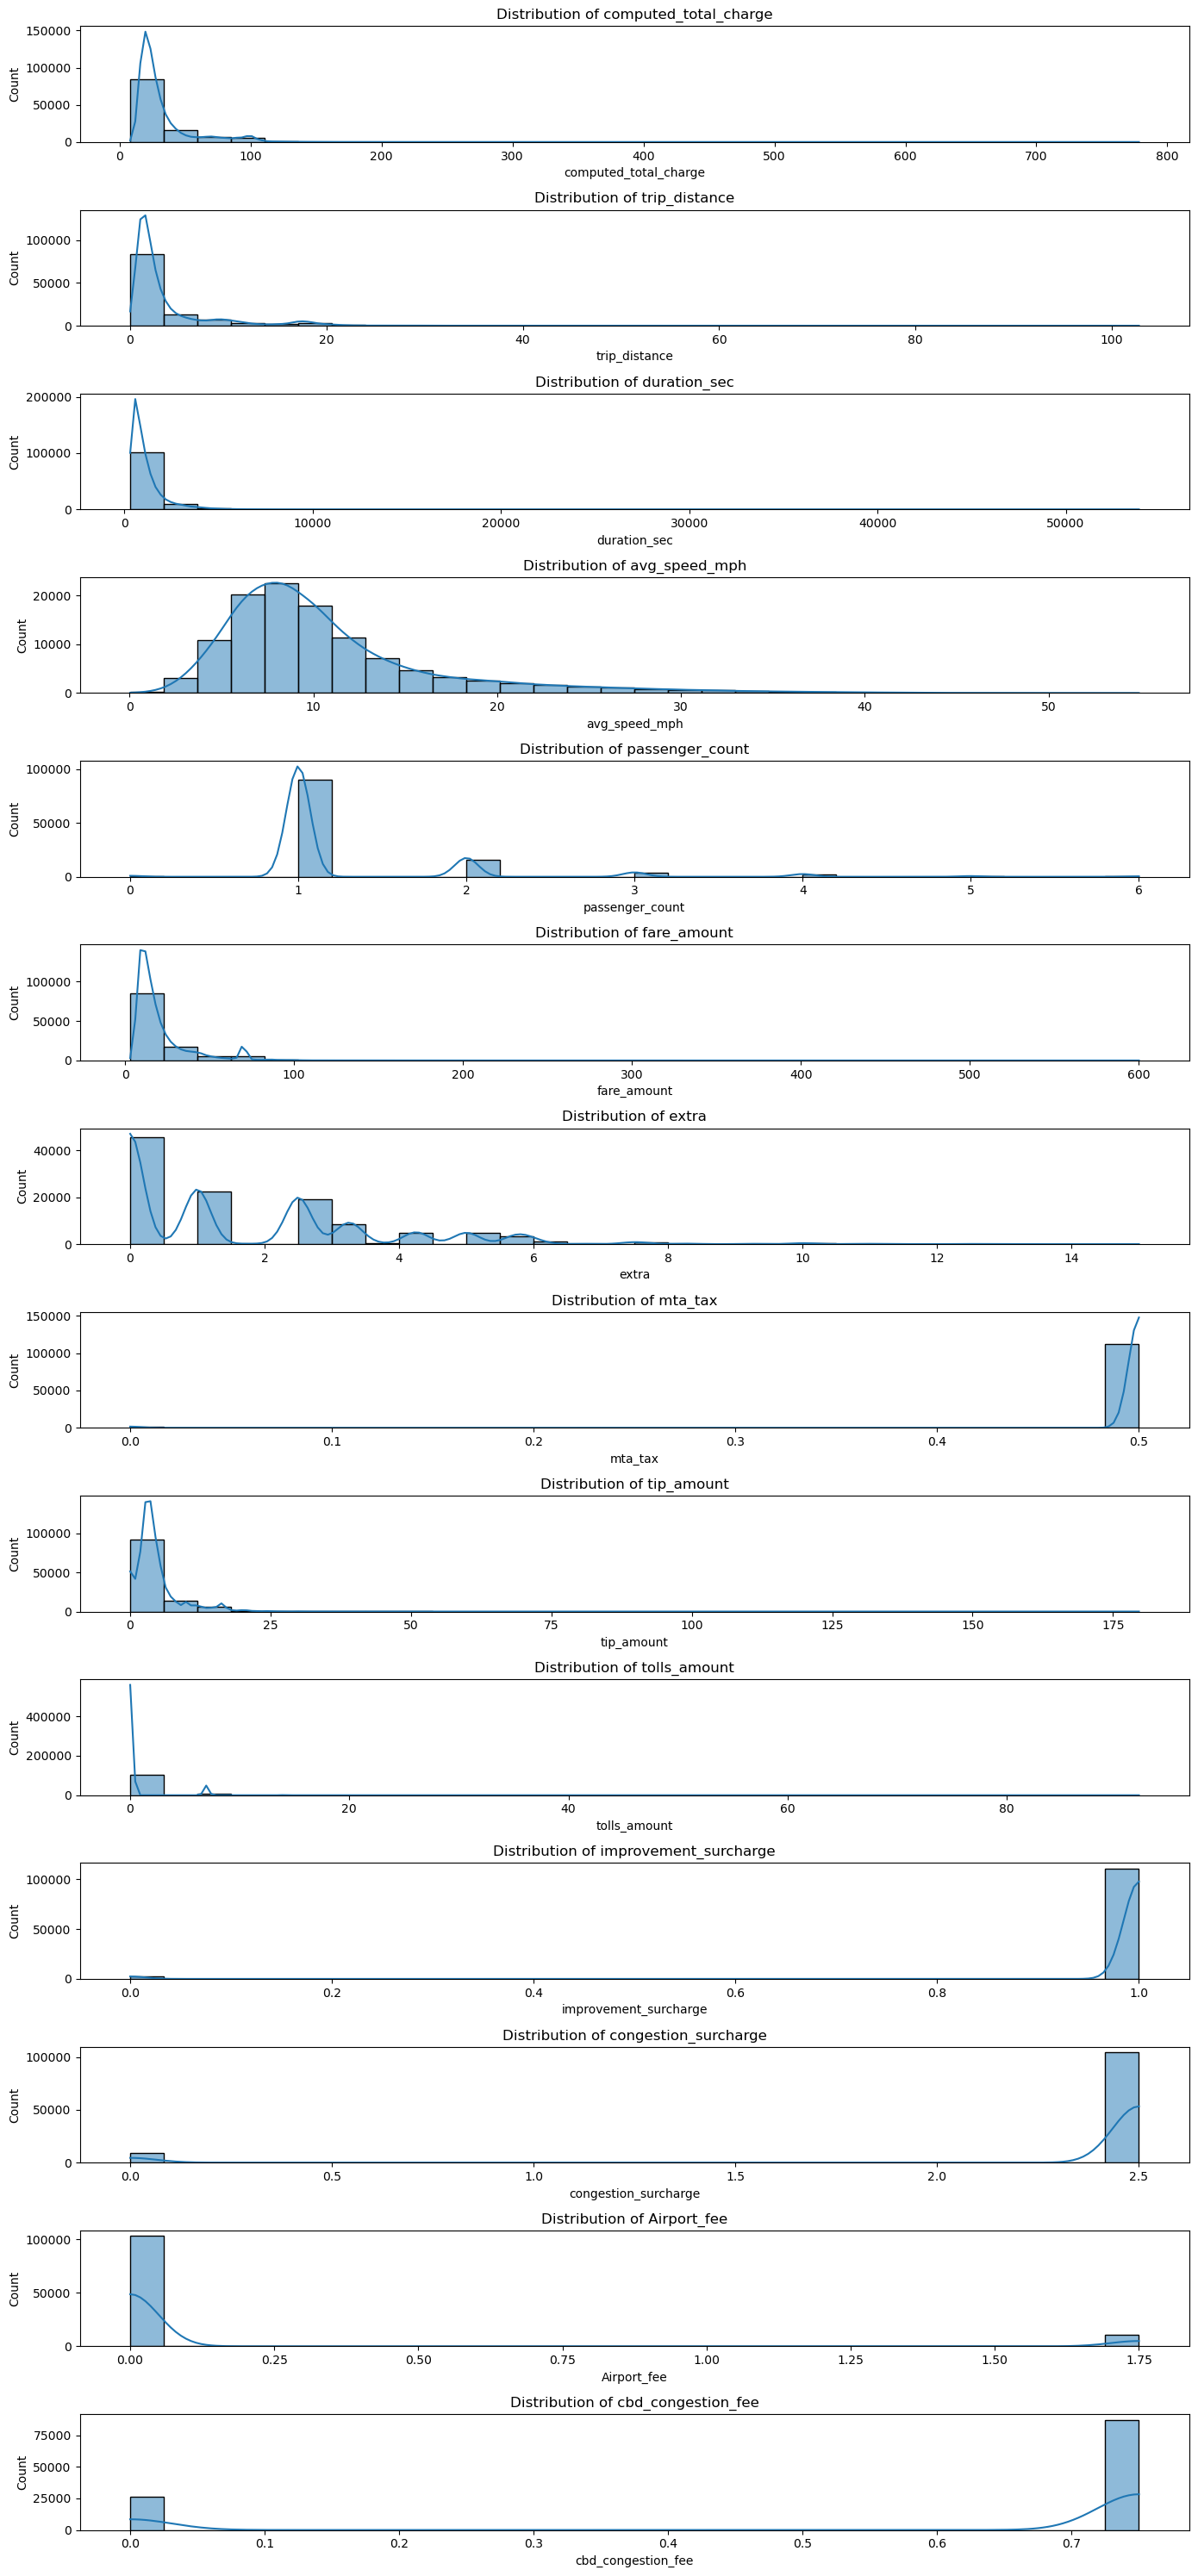

In [14]:
plt.figure(figsize=(14, 30))

for i, col_name in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.histplot(pdf[col_name], kde=True, bins=30)
    plt.title(f"Distribution of {col_name}")
    plt.xlabel(col_name)

plt.tight_layout()
plt.show()

In [15]:
pdf[num_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.995])

,computed_total_charge,trip_distance,duration_sec,avg_speed_mph,passenger_count,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000,113498.000000
mean,32.313014,3.714338,1100.459929,10.777518,1.286076,20.911306,1.683330,0.494568,4.545058,0.659285,0.975489,2.305812,0.160987,0.577180
std,23.479561,4.608807,931.244745,6.218768,0.720536,18.189559,1.984355,0.051831,4.203870,2.324166,0.154631,0.669153,0.505780,0.315831
min,8.000000,0.010000,300.000000,0.025788,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.020000,1.210000,548.000000,6.844485,1.000000,10.000000,0.000000,0.500000,2.460000,0.000000,1.000000,2.500000,0.000000,0.750000
50%,24.060000,1.920000,835.000000,9.152542,1.000000,14.200000,1.000000,0.500000,3.510000,0.000000,1.000000,2.500000,0.000000,0.750000
75%,33.950000,3.660000,1313.750000,12.569832,1.000000,23.300000,2.500000,0.500000,5.050000,0.000000,1.000000,2.500000,0.000000,0.750000
90%,65.450000,9.670000,2098.000000,18.826351,2.000000,43.500000,5.000000,0.500000,9.520000,0.000000,1.000000,2.500000,0.000000,0.750000
95%,89.591500,15.900000,2870.000000,23.975154,3.000000,70.000000,5.750000,0.500000,13.760000,6.940000,1.000000,2.500000,1.750000,0.750000
99.5%,123.726350,22.145150,5110.515000,37.357990,5.000000,93.300000,10.000000,0.500000,21.810300,12.970900,1.000000,2.500000,1.750000,0.750000


#### Box Plot
For detecting outliers

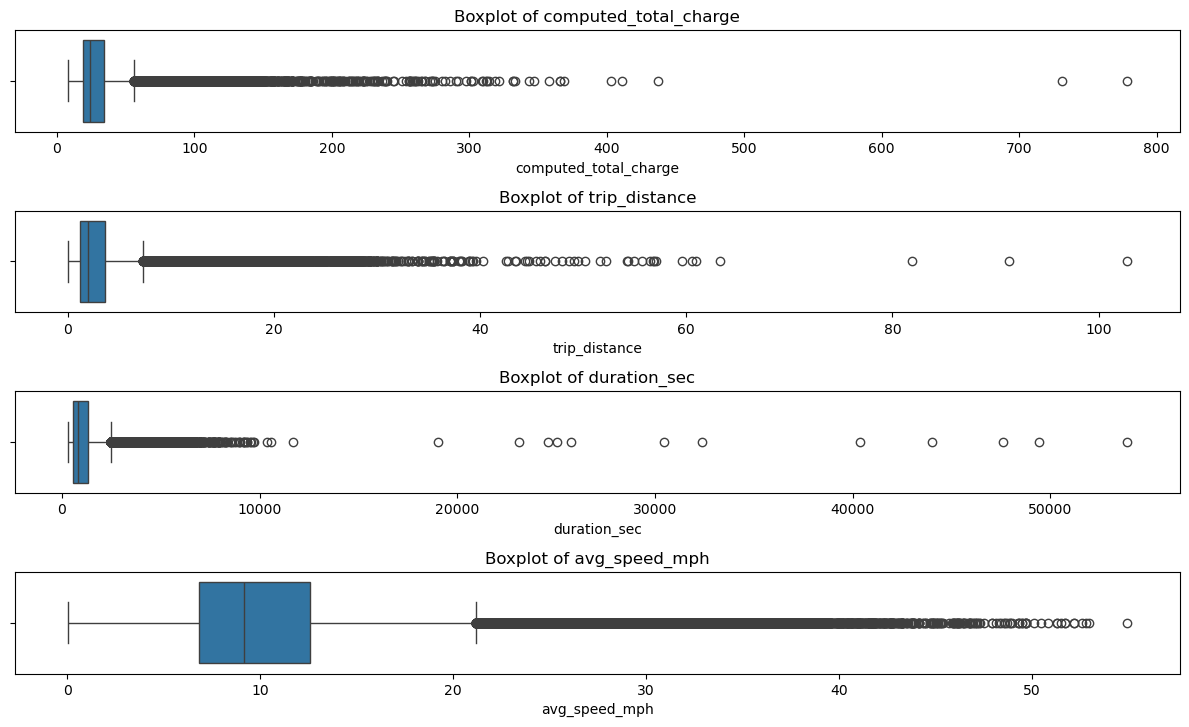

In [16]:
plt.figure(figsize=(12, 25))

for i, col_name in enumerate(["computed_total_charge","trip_distance","duration_sec","avg_speed_mph"], 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=pdf[col_name], orient="h")
    plt.title(f"Boxplot of {col_name}")
    plt.xlabel(col_name)

plt.tight_layout()
plt.show()

In [17]:
# After initial cleaning, the computed_total_charge, trip_distance, and duration_sec are still highly right skewed,
# avg_speed_mph also skewed, but the general distribution is better compared to the other numerical columns

#### Correlation Analysis

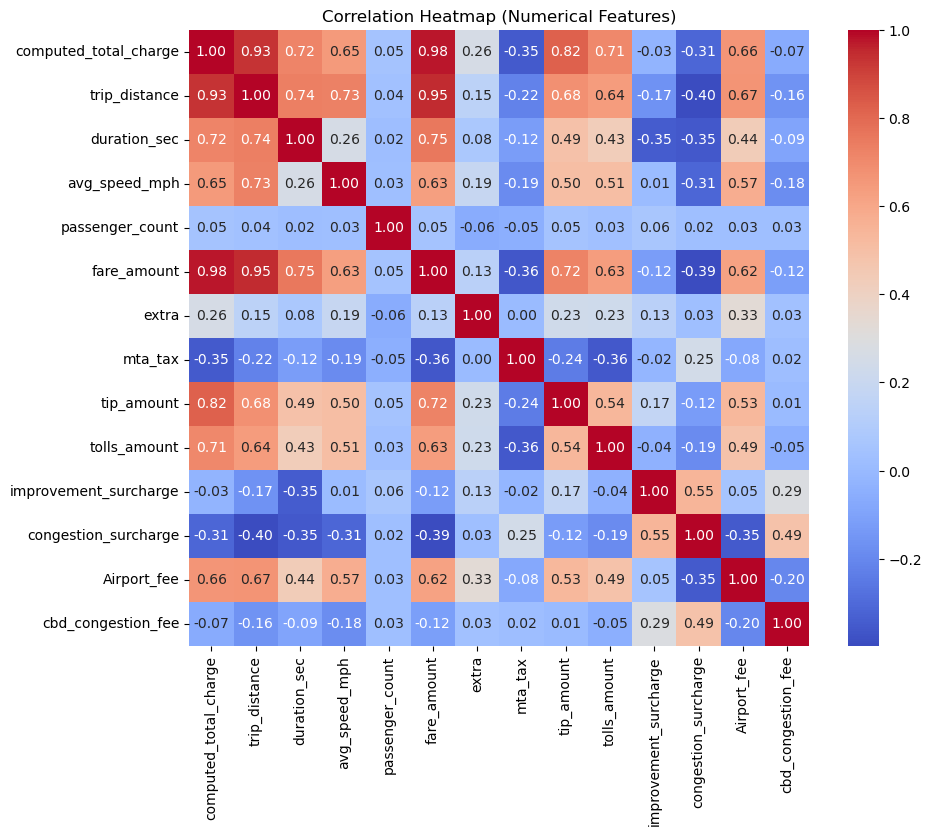

In [18]:
plt.figure(figsize=(10, 8))
corr = pdf[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

Many fare composition columns are high correlated with the target variable (`computed_total_charge`), and these composition features will not be included later in building ML model.

### Categorical Features

#### Countplot

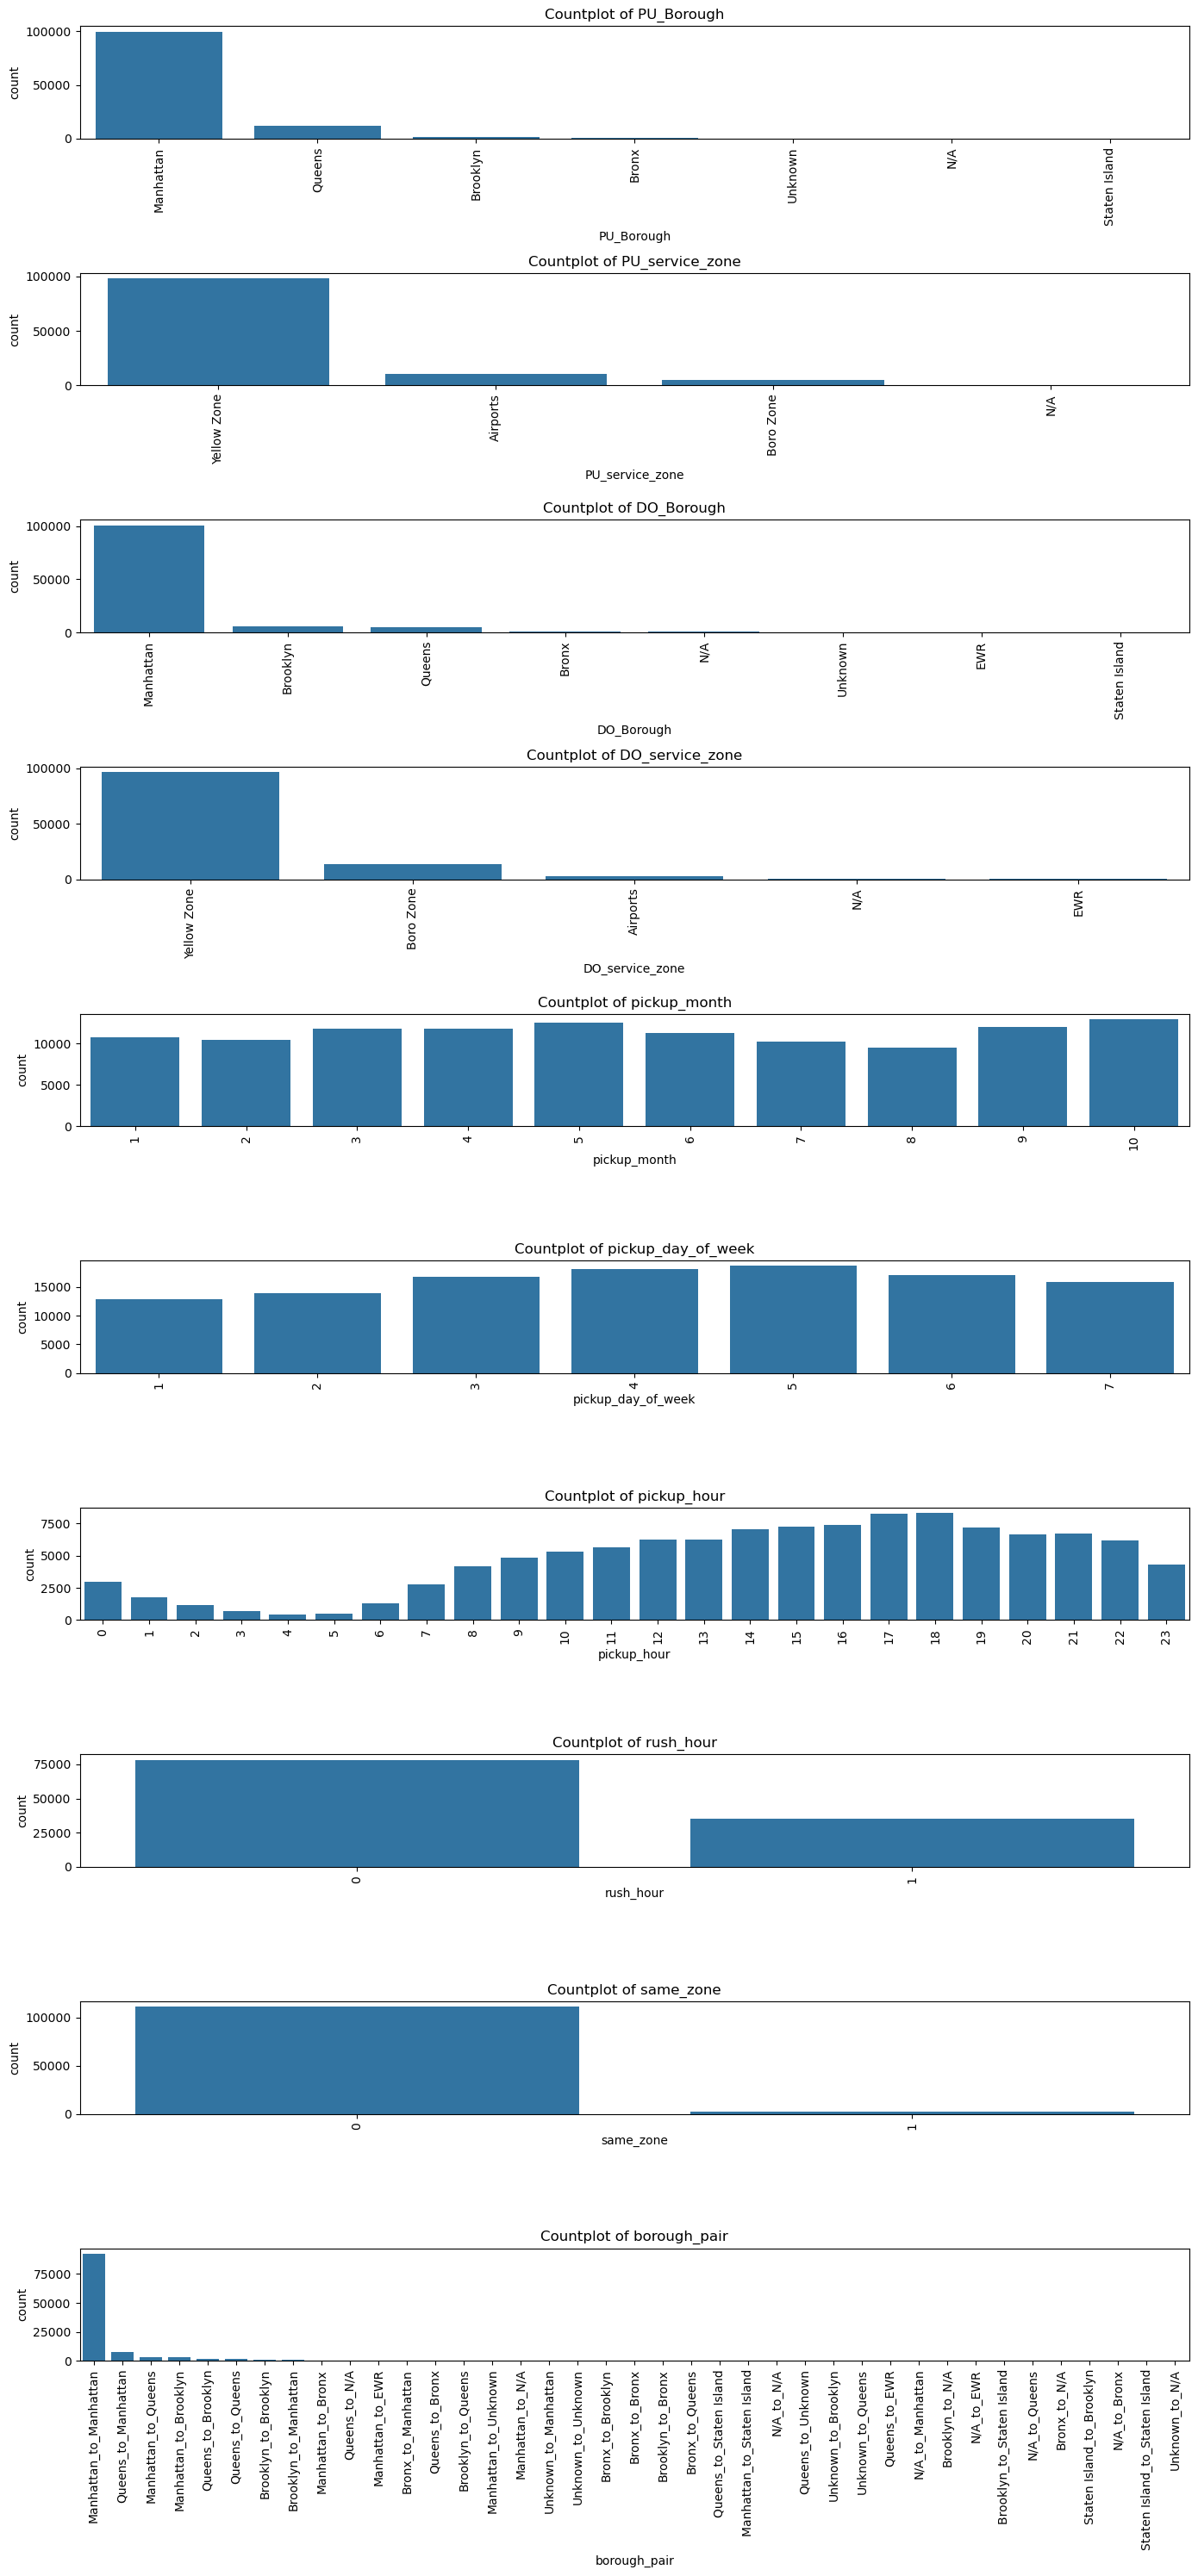

In [19]:
# Creating custom order for pickup_hour and day_of_week
hour_order = list(range(24))       
dow_order = list(range(1, 8))      
month_order = list(range(1,11))

custom_orders = {
    "pickup_hour": hour_order,
    "pickup_day_of_week": dow_order,
    "pickup_month": month_order
}

default_orders = {
    col: pdf[col].value_counts().index.tolist()
    for col in cat_cols
    if col not in custom_orders
}
orders = {**default_orders, **custom_orders}


# Count plot
plt.figure(figsize=(14, 30))

for i, col_name in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    
    sns.countplot(
        data=pdf,
        x=col_name,
        order=orders[col_name] 
    )
    
    plt.title(f"Countplot of {col_name}")
    plt.xticks(rotation=90)
    plt.xlabel(col_name)

plt.tight_layout()
plt.show()

### Relationship Plots
Visualizing relationships between features and target

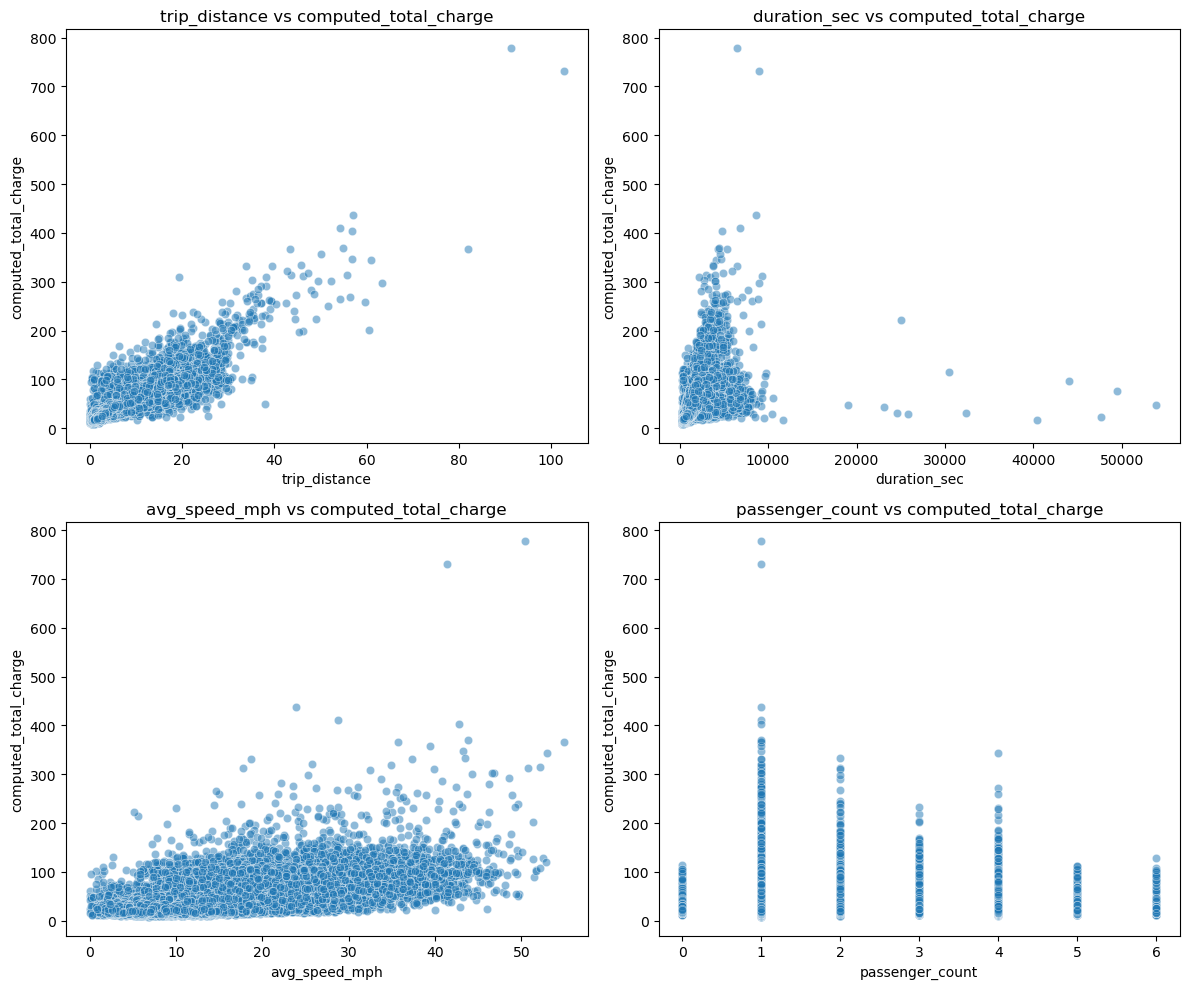

In [20]:
plt.figure(figsize=(12, 10))

for i, col_name in enumerate([
    "trip_distance",
    "duration_sec",
    "avg_speed_mph",
    "passenger_count"
],
    1):
    plt.subplot(2, 2, i)
    sns.scatterplot(
        x=pdf[col_name], 
        y=pdf["computed_total_charge"], 
        alpha=0.5
    )
    plt.title(f"{col_name} vs computed_total_charge")
    plt.xlabel(col_name)
    plt.ylabel("computed_total_charge")

plt.tight_layout()
plt.show()


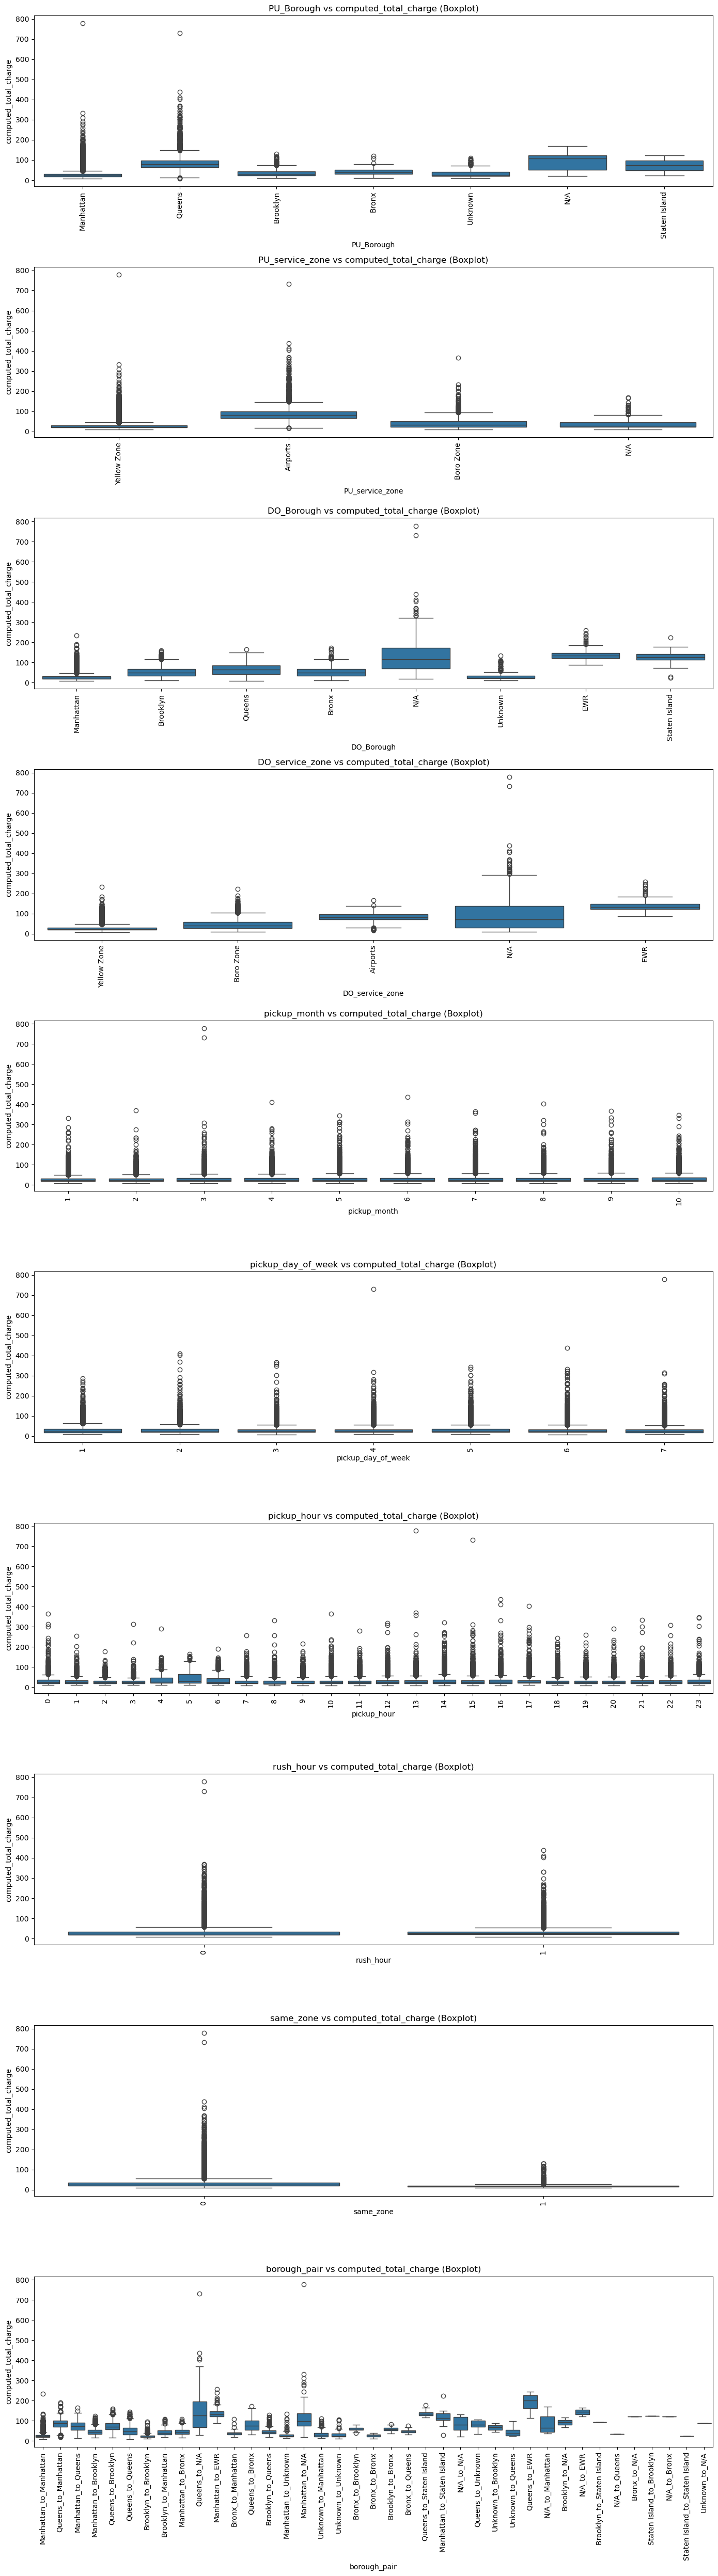

In [21]:

target = "computed_total_charge"

plt.figure(figsize=(14, 5 * len(cat_cols)))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    sns.boxplot(
        data=pdf,
        x=col,
        y=target,
        order=orders[col]
    )
    plt.title(f"{col} vs {target} (Boxplot)")
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Drop Outliers

In [22]:
# Drop the top 1% data in computed_total_charge, trip_distance, and duration_sec
# Drop top and bottom 0.5% data in avg_speed_mph

In [23]:
quantiles = processed_df.approxQuantile(
    ["computed_total_charge", "trip_distance", "duration_sec", "fare_amount", "tip_amount"],
    [0.995],
    0.01
)

q_computed, q_dist, q_dur, q_fare, q_tip  = [q[0] for q in quantiles]

print("Outlier removal thresholds")
print(f"computed_total_charge: {q_computed}")
print(f"trip_distance: {q_dist}")
print(f"duration_sec: {q_dur}")
print(f"fare_amount: {q_fare}")
print(f"tip_amount: {q_tip}")

Outlier removal thresholds
computed_total_charge: 1706.75
trip_distance: 363.1
duration_sec: 53998.0
fare_amount: 1303.6
tip_amount: 960.94


In [24]:
cleaned = (
    processed_df
    .filter(F.col("computed_total_charge") <= q_computed)
    .filter(F.col("trip_distance") <= q_dist)
    .filter(F.col("duration_sec") <= q_dur)
    .filter(F.col("fare_amount") <= q_fare)
    .filter(F.col("tip_amount") <= q_tip)
)

## Data Preparation for Training


In [44]:
def prepare_data(df, sample_fraction=0.02, target_col="computed_total_charge"):
    
    # 1. Sample data to avoid kernel crash
    df_sample = df.sample(False, sample_fraction, seed=42)

    # 2. Numeric features
    num_features = [
        "trip_distance",
        "duration_sec",
        "avg_speed_mph",
        "passenger_count",
        "pickup_hour_sin",
        "pickup_hour_cos"
    ]

    # 3. Categorical features
    cat_features = [
        "PU_Borough", "PU_service_zone",
        "DO_Borough", "DO_service_zone",
        "pickup_month", "pickup_day_of_week",
        "rush_hour",
        "same_zone",
        "borough_pair"
    ]

    # 4. Index categorical columns
    indexers = [
        StringIndexer(
            inputCol=c,
            outputCol=f"{c}_index",
            handleInvalid="keep"
        )
        for c in cat_features
    ]

    # 5. One-hot encode categorical columns
    encoder = OneHotEncoder(
        inputCols=[f"{c}_index" for c in cat_features],
        outputCols=[f"{c}_onehot" for c in cat_features]
    )

    # 6. Assemble numeric + encoded categorical into feature vector
    assembler = VectorAssembler(
        inputCols=num_features + [f"{c}_onehot" for c in cat_features],
        outputCol="features"
    )

    pipeline = Pipeline(stages=indexers + [encoder, assembler])

    # Fit + transform
    pipeline_model = pipeline.fit(df_sample)
    df_transformed = pipeline_model.transform(df_sample)


    # 7. Extract feature names from the assembler model
    feat_metadata = df_transformed.schema["features"].metadata
         
    # 8. Convert feature vector → array → flattened numeric columns
    # Convert Spark ML vector to array
    df_arr = df_transformed.withColumn("features_arr", vector_to_array("features"))

    
    num_f = len(df_arr.select("features_arr").first()[0])
    
    # Create flattened columns
    for i in range(num_f):
        df_arr = df_arr.withColumn(f"f_{i}", df_arr["features_arr"][i])

    df_final = df_arr.drop("features", "features_arr")

    # Keep only feature columns + target column
    feature_cols = [f"f_{i}" for i in range(num_f)]
    df_ready = df_final.select(*feature_cols, target_col)
    
    return df_ready, pipeline_model, feat_metadata

In [45]:
df_ready, pipeline_model, feat_metadata = prepare_data(cleaned, sample_fraction=0.02)

In [47]:
df_ready.show(5)

+----+------+------------------+---+---+---+---+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+---------------------+
| f_0|   f_1|               f_2|f_3|f_4|f_5|f_6|f_7|f_8|f_9|f_10|f_11|f_12|f_13|f_14|f_15|f_16|f_17|f_18|f_19|f_20|f_21|f_22|f_23|f_24|f_25|f_26|f_27|f_28|f_29|f_30|f_31|f_32|f_33|f_34|f_35|f_36|f_37|f_38|f_39|f_40|f_41|f_42|f_43|f_44|f_45|f_46|f_47|f_48|f_49|f_50|f_51|f_52|f_53|f_54|f_55|f_56|f_57|f_58|f_59|f_60|f_61|f_62|f_63|f_64|f_65|f_66|f_67|f_68|f_69|f_70|f_71|f_72|f_73|f_74|f_75|f_76|f_77|f_78|f_79|f_80|f_81|f_82|f_83|f_84|f_85|f_86|f_87|f_88|f_89|f_90|f_91|f_92|f_93|f_94|compute

In [50]:
import json

In [53]:
feat_metadata_path = "gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_training_data_csv/feat_metadata.json"
with open("/tmp/feat_metadata.json", "w") as f:
    json.dump(feat_metadata, f, indent=2)
    
!gsutil cp "/tmp/feat_metadata.json" "gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_training_data_csv/feat_metadata.json"

Copying file:///tmp/feat_metadata.json [Content-Type=application/json]...
/ [1 files][  8.7 KiB/  8.7 KiB]                                                
Operation completed over 1 objects/8.7 KiB.                                      


In [52]:
output_path = "gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_training_data_csv/"
(df_ready
     .coalesce(1)
     .write
     .mode("overwrite")
     .option("header", "true")
     .csv(output_path))